# 12.9. Transfer Learning for Large Image Classification

## Setup

In [1]:
import torch
import torchvision
import torchvision.transforms.v2 as T
from functools import partial
import torch.nn as nn
import torchmetrics
import os
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils import data

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

## Load our Transfer Learning Data

In [3]:
DATA_DIR = 'datasets/hymenoptera_data'
BATCH_SIZE = 32

In [4]:

train_transforms = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

valid_transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [8]:
import copy

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

torch.manual_seed(42)


def make_dataset(folder: str, transforms: T.Compose) -> datasets.ImageFolder:
    return datasets.ImageFolder(os.path.join(DATA_DIR, folder), transforms)

# 1. Instantiate the base training dataset
image_dataset_train_full = make_dataset('train', train_transforms)

# 2. Split it (both train_data and valid_data still point to image_dataset_train_full)
torch.manual_seed(42)
train_data, valid_data = random_split(image_dataset_train_full, [200, 44])

# 3. FIX: Create a shallow clone of the base dataset for validation
# so we can give it different transforms without affecting training.
# We point the valid_data's 'dataset' reference to this new 'clean' version.
valid_dataset_base = copy.copy(image_dataset_train_full)
valid_dataset_base.transform = valid_transforms
valid_data.dataset = valid_dataset_base

# 4. Standard test data (already has valid_transforms)
test_data = make_dataset('val', valid_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")
print(f"Classes: {test_data.classes}")
class_names = test_data.classes

Train: 200, Valid: 44, Test: 153
Classes: ['ants', 'bees']


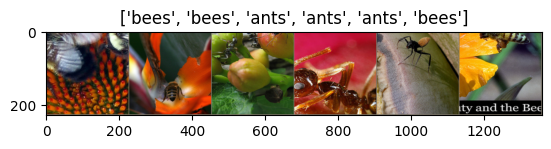

In [12]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

num_items = 6 # out of BATCH_SIZE

# Get a batch of training data
inputs, classes = next(iter(train_loader))
inputs = inputs[:num_items]
classes = classes[:num_items]

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Basic Setup of Train Utilities

In [13]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs, scheduler = None):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate_tm(model, valid_loader, metric).item())
        if scheduler is not None:
            scheduler.step()
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

def use_lecun_init(module: nn.Module):
    if isinstance(module, nn.Linear) or isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
        nn.init.zeros_(module.bias)


## Get some pretrained model

I'll go with ResNet since it's a decent baseline and the goal here is mostly just an exercise...

In [14]:
[name for name in torchvision.models.list_models() if "resnet" in name]

['deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'keypointrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'quantized_resnet18',
 'quantized_resnet50',
 'resnet101',
 'resnet152',
 'resnet18',
 'resnet34',
 'resnet50',
 'retinanet_resnet50_fpn',
 'retinanet_resnet50_fpn_v2',
 'wide_resnet101_2',
 'wide_resnet50_2']

In [15]:
weights = torchvision.models.ResNet34_Weights.IMAGENET1K_V1
model = torchvision.models.resnet34(weights=weights).to(device)

In [16]:
list(torchvision.models.get_model_weights("resnet34"))

[ResNet34_Weights.IMAGENET1K_V1]

In [17]:
transform = weights.transforms()
transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [18]:
train_transforms

Compose(
      RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [19]:
valid_transforms

Compose(
      Resize(size=[256], interpolation=InterpolationMode.BILINEAR, antialias=True)
      CenterCrop(size=(224, 224))
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

Okay so we could actually use that provided transform in the dataloader instead... but mine (taken from [the tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) just happen to match up). So I'll stick to them.

## Train (Finetune) step

### Replace the head and freeze the other weights

In [20]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

New head for our classification target

In [21]:
model.fc = nn.Linear(in_features=512, out_features=len(test_data.classes)).to(device)

freeze all but the head

In [22]:
[param for param in model.named_parameters()]

[('conv1.weight',
  Parameter containing:
  tensor([[[[ 5.4109e-03, -6.9092e-03,  7.8839e-03,  ...,  4.9072e-02,
              3.0660e-02,  2.5398e-02],
            [ 4.1081e-02,  3.1296e-02,  3.2265e-02,  ...,  3.3145e-02,
              2.9754e-02,  4.1735e-02],
            [ 4.9519e-03, -3.1705e-02, -6.1310e-02,  ..., -9.7493e-02,
             -1.1601e-01, -1.2191e-01],
            ...,
            [-1.2287e-02, -2.4841e-02, -9.3052e-03,  ...,  1.7113e-02,
              2.4631e-03,  1.6726e-02],
            [ 3.9117e-03,  4.4537e-03,  3.6315e-02,  ...,  1.0371e-01,
              7.3973e-02,  5.9085e-02],
            [ 1.6784e-02,  8.8902e-03,  3.1312e-02,  ...,  9.6964e-02,
              8.3749e-02,  9.6970e-02]],
  
           [[-7.7192e-03, -8.7711e-03,  1.4143e-02,  ...,  3.3901e-02,
              2.5483e-02,  2.4275e-02],
            [ 5.3961e-02,  4.4677e-02,  3.4326e-02,  ...,  1.3392e-02,
              1.9135e-02,  3.7995e-02],
            [ 1.0251e-03, -5.4513e-02, -1.0225e-0

In [23]:
"aaaa".startswith("fc.")

False

Freeze all but our new `fc` output head

In [24]:
for param_name, param in model.named_parameters():
    if param_name.startswith("fc."):
        continue

    param.requires_grad = False

### Training

So since this is fine-tuning, we start at a small LR

In [25]:
torch.manual_seed(42)

n_epochs = 30

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=len(test_data.classes)
).to(device)


cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=0.00001
)

model.train()
history = train(
    model,
    optimizer,
    xentropy,
    accuracy,
    train_loader,
    valid_loader,
    n_epochs,
    scheduler=cosine_scheduler
)

Epoch 1/30, train loss: 0.6610, train metric: 0.6100, valid metric: 0.7273
Epoch 2/30, train loss: 0.4683, train metric: 0.7900, valid metric: 0.8636
Epoch 3/30, train loss: 0.4025, train metric: 0.8450, valid metric: 0.8864
Epoch 4/30, train loss: 0.3454, train metric: 0.8850, valid metric: 0.9091
Epoch 5/30, train loss: 0.2879, train metric: 0.9000, valid metric: 0.9318
Epoch 6/30, train loss: 0.2622, train metric: 0.9300, valid metric: 0.9545
Epoch 7/30, train loss: 0.2506, train metric: 0.9100, valid metric: 0.9545
Epoch 8/30, train loss: 0.2227, train metric: 0.9050, valid metric: 0.9545
Epoch 9/30, train loss: 0.2484, train metric: 0.9150, valid metric: 0.9545
Epoch 10/30, train loss: 0.2467, train metric: 0.9150, valid metric: 0.9545
Epoch 11/30, train loss: 0.2378, train metric: 0.9050, valid metric: 0.9545
Epoch 12/30, train loss: 0.2450, train metric: 0.9200, valid metric: 0.9545
Epoch 13/30, train loss: 0.2171, train metric: 0.9250, valid metric: 0.9545
Epoch 14/30, train lo

Evaluate on the test set

In [26]:
evaluate_tm(model, test_loader, accuracy)

tensor(0.9608, device='cuda:0')

I liked my confusion matrix from the prev thing so I'll reuse it here out of curiosity

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from torchmetrics import ConfusionMatrix
import numpy as np

def plot_confusion_matrix(model, data_loader, device, classes, error_only = False):
    # 1. Initialize the metric
    confmat = ConfusionMatrix(task="multiclass", num_classes=len(classes)).to(device)
    model.eval()

    # 2. Collect predictions
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            confmat.update(y_pred, y_batch)

    # 3. Compute and move to CPU for plotting
    cm = confmat.compute().cpu().numpy()
    if error_only:
        np.fill_diagonal(cm, 0)

    # 4. Plot using Seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Reds',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [28]:
len(test_data)

153

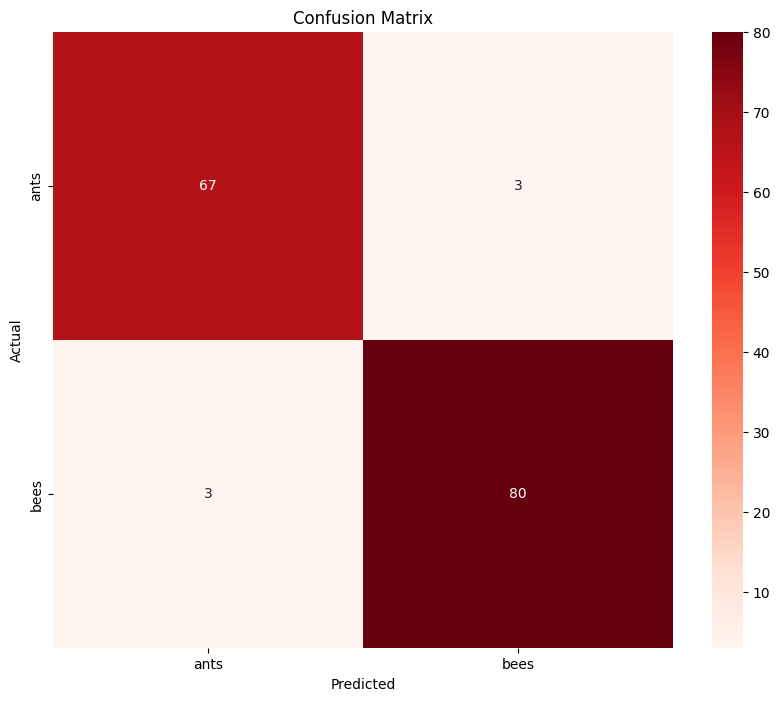

In [29]:
plot_confusion_matrix(model, test_loader, device, test_data.classes, error_only=False)

In [30]:

import matplotlib.pyplot as plt
import numpy as np

def get_model_failures(model: nn.Module, data_loader: DataLoader, device: str, n_max: int=10):
    model.eval()
    failed_images = []
    failed_labels = []
    pred_labels = []

    failed_image_indices = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            preds = torch.argmax(y_pred, dim=1)

            # find incides where prediction != truth
            mask = preds != y_batch

            if mask.any():
                failed_images.append(X_batch[mask].cpu())
                failed_labels.append(y_batch[mask].cpu())
                pred_labels.append(preds[mask].cpu())

                failed_image_indices.append(mask.nonzero().cpu())

            if len(failed_images) >= n_max:
                break

    img = torch.cat(failed_images)[:n_max]
    truths = torch.cat(failed_labels)[:n_max]
    preds = torch.cat(pred_labels)[:n_max]

    return img, truths, preds, failed_image_indices


def show_failures(imgs, labels, preds, classes):
    # The 'Science' of seeing: reverse the ImageNet normalization
    # mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    plt.figure(figsize=(15, 10))
    for i in range(len(imgs)):
        plt.subplot(2, 5, i + 1)

        # Convert (C, H, W) Tensor -> (H, W, C) Numpy
        img = imgs[i].permute(1, 2, 0).numpy()

        # Undo normalization: img = (img * std) + mean
        img = std * img + mean
        img = np.clip(img, 0, 1) # Ensure pixel values are in [0, 1]

        plt.imshow(img)
        plt.title(f"T: {classes[labels[i]]}\nP: {classes[preds[i]]}")
        plt.axis('off')
    plt.show()

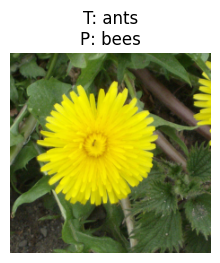

In [ ]:
err_imgs, err_truths, err_preds, failed_image_indices = get_model_failures(model, valid_loader, device, n_max=10)
display_labels = [f"True: {t.item()}, Pred: {p.item()}" for t, p in zip(err_truths, err_preds)]
show_failures(err_imgs, err_truths, err_preds, test_data.classes)

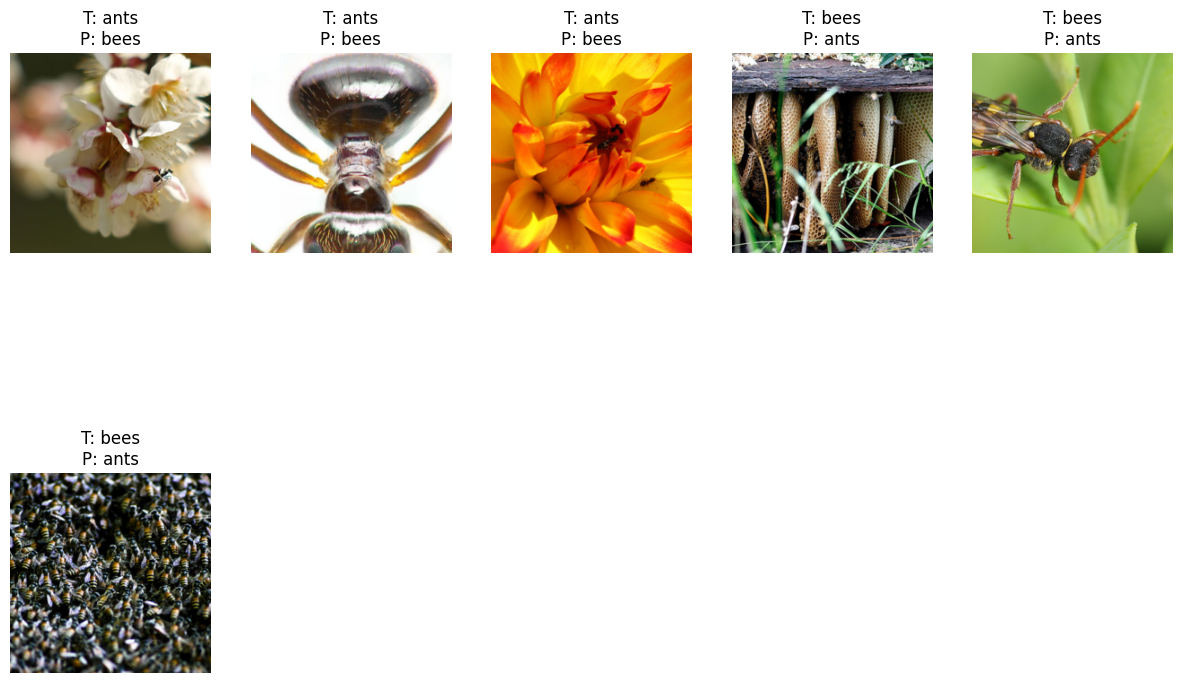

In [34]:
err_imgs, err_truths, err_preds, failed_image_indices = get_model_failures(model, test_loader, device, n_max=10)
display_labels = [f"True: {t.item()}, Pred: {p.item()}" for t, p in zip(err_truths, err_preds)]
show_failures(err_imgs, err_truths, err_preds, test_data.classes)